# Lab Instructions

You are part of a data team for a financial institution that uses an AI model to determine who will and will not be granted a loan.  Recently, there have been complaints from customers that the model unfairly discriminates based on the applicant's age and sex. A court has ordered that the financial institution must provide information about how the model works.  

Data from recent loan applications is given in `loan_data.csv`.  The data dictionary is below:

| Feature              | Description | Data Type |
| :---------------- | :------: | ----: |
|person_age|Age of the person|Float
|person_gender|Gender of the person|Categorical
|person_education|Highest education level|Categorical
|person_income|Annual income|Float
|person_emp_exp|Years of employment experience|Integer
|person_home_ownership|Home ownership status (e.g., rent, own, mortgage)|Categorical
|loan_amnt|Loan amount requested|Float
|loan_intent|Purpose of the loan|Categorical
|loan_int_rate|Loan interest rate|Float
|loan_percent_income|Loan amount as a percentage of annual income|Float
|cb_person_cred_hist_length|Length of credit history in years|Float
|credit_score|Credit score of the person|Integer
|previous_loan_defaults_on_file|Indicator of previous loan defaults|Categorical
|loan_status (target variable)|Loan approval status: 1 = approved; 0 = rejected|Integer

Visualize the relationship between age, sex and 5 other features with `loan_status`.  Which features seem to drive the model's decision to grant a loan?  Which seem unrelated?  Should the financial institution be concerned about potential legal trouble?  Make sure to justify your answers with specific references to your visualizations.



In [1]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt


df = pd.read_csv('loan_data.csv')
print(df.head())

   person_age person_gender person_education  person_income  person_emp_exp  \
0          71          male        Associate   46817.176426               3   
1          34          male      High School   79093.494008              17   
2          80          male        Associate   67819.614431              20   
3          40        female        Associate   49599.861220               0   
4          43          male        Doctorate   99833.900180               8   

  person_home_ownership     loan_amnt loan_intent  loan_int_rate  \
0                  RENT  11567.737650     MEDICAL      10.351469   
1                   OWN   9519.674498     MEDICAL      11.168902   
2                   OWN  16226.604002    PERSONAL      12.293112   
3                  RENT  15641.221708     VENTURE      10.327926   
4                   OWN  12727.942517   EDUCATION       9.338069   

   loan_percent_income  cb_person_cred_hist_length  credit_score  \
0             0.247083                          

In [3]:
# Summary of dataframe, including data types and non-null values
print(df.info())

# Descriptive statistics for numerical columns
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  int64  
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  int64  
 11  credit_score                    45000 non-null  float64
 12  previous_loan_defaults_on_file  

In [ ]:
"""Visualize the relationship between age, sex and 5 other features with loan_status. 
Which features seem to drive the model's decision to grant a loan? Which seem unrelated?
Should the financial institution be concerned about potential legal trouble? Make sure to
justify your answers with specific references to your visualizations.

1. person_income
2. credit_score
3. loan_int_rate
4. person_home_ownership
5.loan_intent
"""

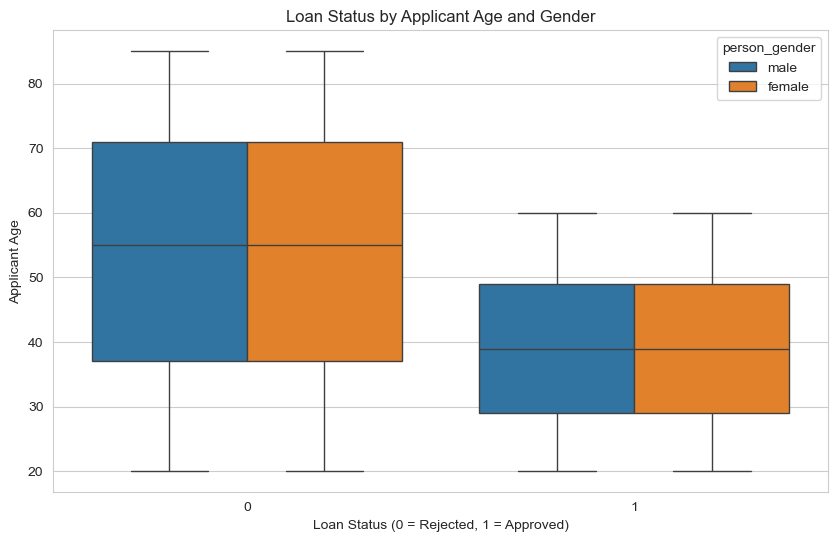

In [5]:
sns.set_style("whitegrid")

# Create boxplot to visualize Age vs. Loan Status and split by Gender
plt.figure(figsize=(10,6))
sns.boxplot(x='loan_status', y='person_age', hue='person_gender', data=df)
plt.title('Loan Status by Applicant Age and Gender')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Applicant Age')
plt.show()

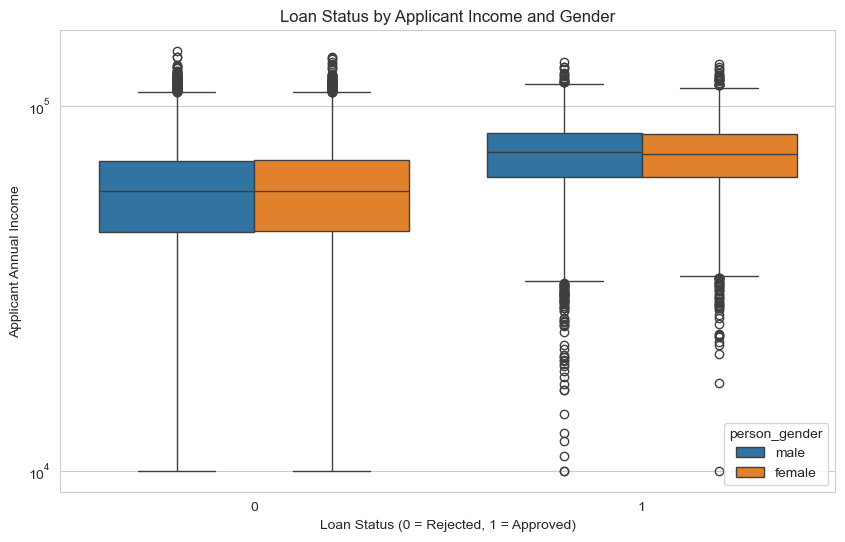

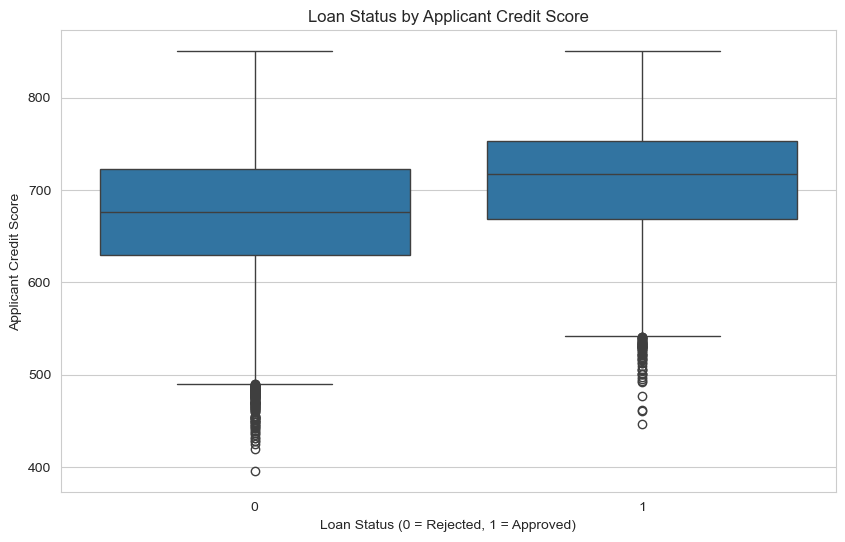

In [6]:
# Create boxplot for Income vs. Loan Status, split by Gender
plt.figure(figsize=(10, 6))
sns.boxplot(x='loan_status', y='person_income', hue='person_gender', data=df)
plt.title('Loan Status by Applicant Income and Gender')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Applicant Annual Income')
plt.yscale('log')
plt.show()

# Create a boxplot for Credit Score vs. Loan Status
plt.figure(figsize=(10, 6))
sns.boxplot(x='loan_status', y='credit_score', data=df)
plt.title('Loan Status by Applicant Credit Score')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Applicant Credit Score')
plt.show()

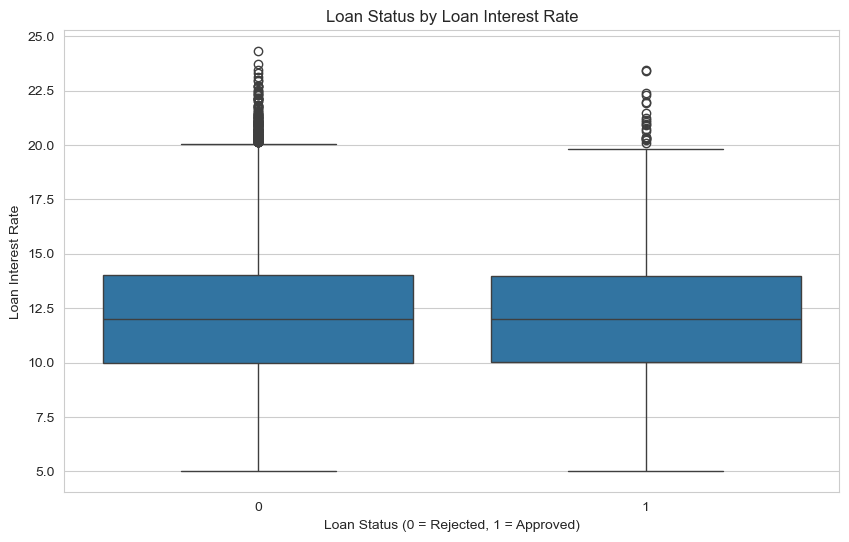

In [8]:
# Visualizing Loan Interest Rate vs. Loan Status
plt.figure(figsize=(10, 6))
sns.boxplot(x='loan_status', y='loan_int_rate', data=df)
plt.title('Loan Status by Loan Interest Rate')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Loan Interest Rate')
plt.show()

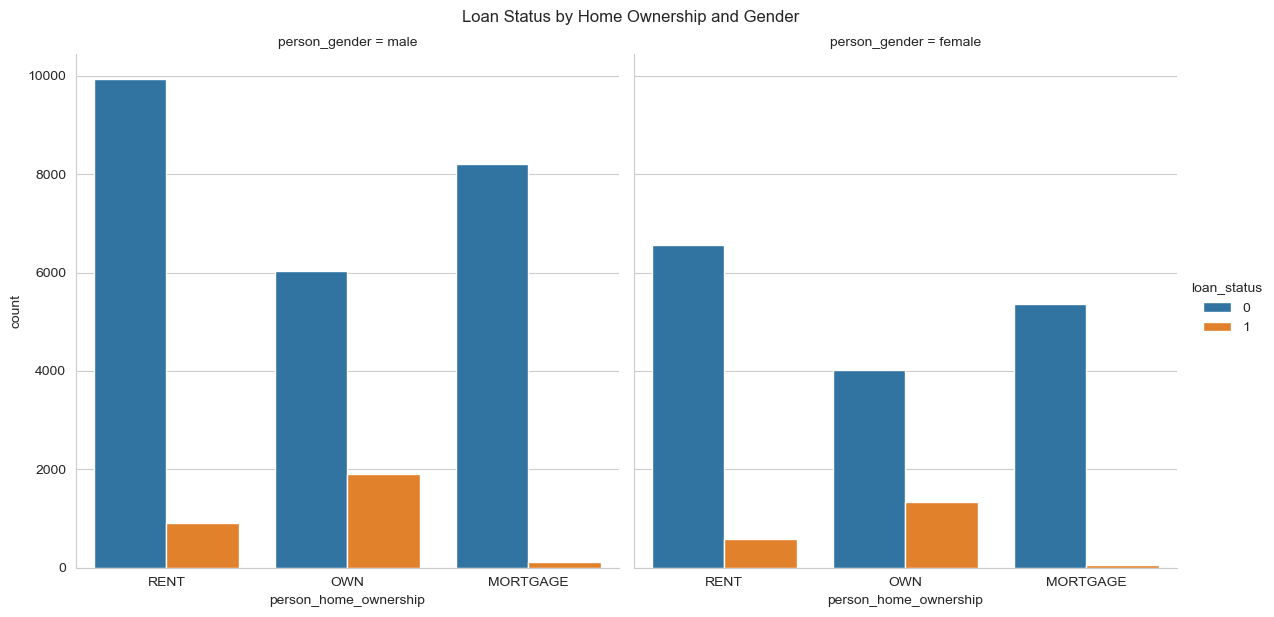

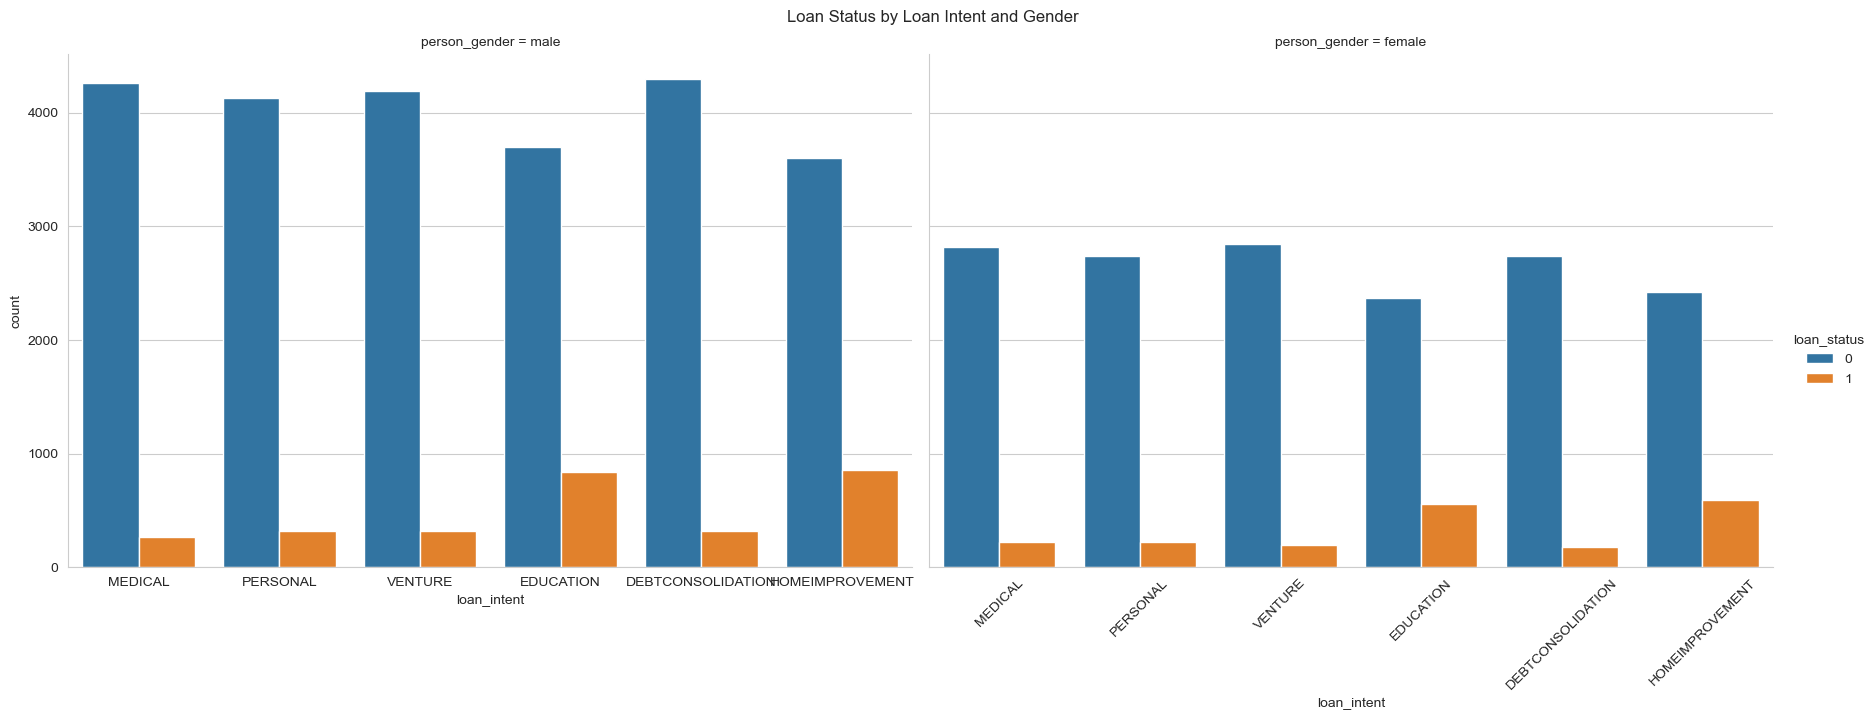

In [7]:
# Visualizing Loan Status by Home Ownership, faceted by Gender
sns.catplot(x='person_home_ownership', hue='loan_status', col='person_gender',
            data=df, kind='count', height=6, aspect=1)
plt.suptitle('Loan Status by Home Ownership and Gender', y=1.02)
plt.show()

# Visualizing Loan Status by Loan Intent, faceted by Gender
sns.catplot(x='loan_intent', hue='loan_status', col='person_gender',
            data=df, kind='count', height=6, aspect=1.5)
plt.suptitle('Loan Status by Loan Intent and Gender', y=1.02)
# Rotate x-axis labels for better readability
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Interpretation and Analysis

## Age & Gender vs. Loan Status
"""
Looking at the first boxplot for Loan Status by Applicant Age and Gender we can see
that the distribution of age for approved (1) and rejected (0) loans are very similar.
Within both approved and rejected categories, the age distributions for Male and Female
are nearly identical.

This suggests that Age and Gender can not be strong drivers of the loan decision. An older
applicant is not more likely to be approved than a younger one, and men and women 
have similar age profiles for approval and rejection.
"""

## Income and Credit Score vs. Loan Status
"""
In the income plot we can see a clear difference: median income for approved loans is significantly 
higher than for rejected loans. This is the similar for both genders.
The credit Score plot shows a stronger trend: with a higher credit score loans are approved more, there
is almost no overlap between the box of credit scores for rejected and approved loans.

Income and credit score are primary drivers of this models decision. This is standard and expected practice
for loan applications.
"""

## Loan Interest Rate vs Loan Status
"""
The interest rate boxplot shows a clear pattern: approved loans tend to have lower interest rates, 
while rejected loans are associated with higher rates. This makes sense, as higher-risk applicants 
are usually offered higher rates, and many of those applications may be rejected outright. 

This suggests that loan interest rate is an important driver of approval decisions, reinforcing the 
idea that the model heavily relies on financial risk indicators such as credit score, income, and 
loan terms, rather than demographic features like age or gender.
"""

## Home Ownership and Loan Intent vs. Loan Status
"""
The home ownership plot shows that people with a mortgage have a very high approval rating where as people
who rent have a much higher rejection rate. This trend is consistent across both genders.
Loan intent plot shows that loans for certain purposes (debt consolidation or home improvement) seem to have a 
higher approval than those for other purposes (personal or venture).

Home Ownership status and the purpose for the loan are important factors based on these findings. The model
appears to favor applicants who are financially established (own a home) and are seeking loans for specific, 
lower-risk purposes.
"""